In [ ]:
## 0 — Mount Drive & Check GPU

from google.colab import drive
drive.mount('/content/drive')

import torch
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU detected. Go to Runtime → Change runtime type → T4 GPU')

Mounted at /content/drive
PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4
VRAM            : 15.6 GB


In [ ]:
import subprocess
result = subprocess.run('du -sh /content/*',
                       capture_output=True, text=True, shell=True)
print(result.stdout)

130G	/content/drive
55M	/content/sample_data



In [ ]:
import subprocess, time, os

if os.path.exists('/content/preprocessed'):
    print('Already exists — skipping copy.')
else:
    print('Copying to SSD...')
    t0 = time.time()
    subprocess.run([
        'rsync', '-ah', '--info=progress2',
        '/content/drive/MyDrive/FloodProject/data/preprocessed/',
        '/content/preprocessed/'
    ], capture_output=False)
    print(f'Done in {(time.time()-t0)/60:.1f} mins.')

Copying to SSD...


KeyboardInterrupt: 

In [ ]:
## 1 — Configuration

import os, json, glob, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# ── Paths ─────────────────────────────────────────────────────────────────
DATA_BASE = '/content/drive/MyDrive/FloodProject/data/preprocessed'
MODEL_DIR  = '/content/drive/MyDrive/FloodProject/models/unet_spatial'
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Training config ────────────────────────────────────────────────────────
BATCH_SIZE   = 4
NUM_WORKERS = 2
PIN_MEMORY  = True
LR           = 1e-4
MAX_EPOCHS   = 100
PATIENCE     = 10       # early stopping patience
RANDOM_SEED  = 42

# ── Model config ───────────────────────────────────────────────────────────
IN_CHANNELS  = 14       # VV,VH,B2,B3,B4,B8,B11,B12,Elev,Slope,TWI,HAND,NDWI,NDVI
OUT_CHANNELS = 1        # binary flood mask

# ── Device ─────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# ── Reproducibility ────────────────────────────────────────────────────────
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

print('Configuration loaded.')

Device: cuda
Configuration loaded.


In [ ]:
## 2 — Dataset

class FloodDataset(Dataset):
    """
    Loads preprocessed spatial .npy chips for U-Net training.
    Temporal data is NOT used in this variant.

    Returns:
        spatial : (14, 512, 512) float32 tensor — normalized
        label   : (512, 512) int16 tensor — 0/1/-1
    """
    def __init__(self, data_dir, augment=False):
        self.data_dir = data_dir
        self.augment  = augment
        # Find all chips by scanning for spatial files
        sp_files = sorted(glob.glob(f'{data_dir}/*_spatial.npy'))
        self.chip_ids = [
            os.path.basename(f).replace('_spatial.npy', '')
            for f in sp_files
        ]
        print(f'Dataset: {len(self.chip_ids)} chips from {data_dir}')

    def __len__(self):
        return len(self.chip_ids)

    def __getitem__(self, idx):
        chip_id = self.chip_ids[idx]

        # Load spatial and label — lazy, one chip at a time
        spatial = np.load(f'{self.data_dir}/{chip_id}_spatial.npy')  # (14, 512, 512)
        label   = np.load(f'{self.data_dir}/{chip_id}_label.npy')    # (512, 512)

        # Augmentation — apply same transform to both spatial and label
        if self.augment:
            spatial, label = self._augment(spatial, label)

        spatial = torch.from_numpy(spatial.astype(np.float32))        # (14, 512, 512)
        label   = torch.from_numpy(label.astype(np.int16))            # (512, 512)
        return spatial, label

    def _augment(self, spatial, label):
        """Random horizontal flip, vertical flip, 90° rotation."""
        # Horizontal flip
        if random.random() > 0.5:
            spatial = spatial[:, :, ::-1].copy()
            label   = label[:, ::-1].copy()
        # Vertical flip
        if random.random() > 0.5:
            spatial = spatial[:, ::-1, :].copy()
            label   = label[::-1, :].copy()
        # 90° rotation (k = 0,1,2,3)
        k = random.randint(0, 3)
        if k > 0:
            spatial = np.rot90(spatial, k, axes=(1, 2)).copy()
            label   = np.rot90(label,   k, axes=(0, 1)).copy()
        return spatial, label


# ── Build datasets ─────────────────────────────────────────────────────────
train_dataset = FloodDataset(f'{DATA_BASE}/train', augment=True)
val_dataset   = FloodDataset(f'{DATA_BASE}/val',   augment=False)

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = NUM_WORKERS,
    pin_memory  = PIN_MEMORY,
    drop_last   = True,       # avoids batch norm issues with batch size 1
)
val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = PIN_MEMORY,
)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches  : {len(val_loader)}')

# Quick shape check
sp, lb = next(iter(train_loader))
print(f'Batch spatial shape : {sp.shape}   dtype={sp.dtype}')
print(f'Batch label shape   : {lb.shape}   dtype={lb.dtype}')
print(f'Label unique values : {lb.unique().tolist()}')

Dataset: 2064 chips from /content/drive/MyDrive/FloodProject/data/preprocessed/train
Dataset: 168 chips from /content/drive/MyDrive/FloodProject/data/preprocessed/val
Train batches: 516
Val batches  : 42
Batch spatial shape : torch.Size([4, 14, 512, 512])   dtype=torch.float32
Batch label shape   : torch.Size([4, 512, 512])   dtype=torch.int16
Label unique values : [-1, 0, 1]


In [ ]:
## 3 — U-Net Architecture

class ConvBlock(nn.Module):
    """Two 3×3 conv layers with BatchNorm and ReLU."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    """MaxPool → ConvBlock (encoder step)."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = ConvBlock(in_ch, out_ch)
    def forward(self, x):
        return self.conv(self.pool(x))


class Up(nn.Module):
    """Bilinear upsample → concat skip → ConvBlock (decoder step)."""
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = ConvBlock(in_ch + skip_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    """
    Standard U-Net with 4 encoder levels.
    Input  : (B, in_channels, 512, 512)
    Output : (B, 1, 512, 512) — raw logits (apply sigmoid for probability)

    Encoder filter sizes: 64 → 128 → 256 → 512
    Bottleneck          : 1024
    Total params        : ~31M
    """
    def __init__(self, in_channels=14, out_channels=1):
        super().__init__()
        # Encoder
        self.enc1 = ConvBlock(in_channels, 64)
        self.enc2 = Down(64,  128)
        self.enc3 = Down(128, 256)
        self.enc4 = Down(256, 512)
        # Bottleneck
        self.bottleneck = Down(512, 1024)
        # Decoder
        self.dec4 = Up(1024, 512, 512)
        self.dec3 = Up(512,  256, 256)
        self.dec2 = Up(256,  128, 128)
        self.dec1 = Up(128,  64,  64)
        # Output
        self.out  = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)          # (B, 64,   512, 512)
        e2 = self.enc2(e1)         # (B, 128,  256, 256)
        e3 = self.enc3(e2)         # (B, 256,  128, 128)
        e4 = self.enc4(e3)         # (B, 512,   64,  64)
        # Bottleneck
        b  = self.bottleneck(e4)   # (B, 1024,  32,  32)
        # Decoder
        d4 = self.dec4(b,  e4)     # (B, 512,   64,  64)
        d3 = self.dec3(d4, e3)     # (B, 256,  128, 128)
        d2 = self.dec2(d3, e2)     # (B, 128,  256, 256)
        d1 = self.dec1(d2, e1)     # (B, 64,   512, 512)
        return self.out(d1)        # (B, 1,    512, 512)


# ── Instantiate and check ──────────────────────────────────────────────────
model = UNet(in_channels=IN_CHANNELS, out_channels=OUT_CHANNELS).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'U-Net parameters: {n_params/1e6:.1f}M')

# Forward pass shape check with dummy input
with torch.no_grad():
    dummy = torch.randn(1, IN_CHANNELS, 512, 512).to(DEVICE)
    out   = model(dummy)
    print(f'Input shape  : {dummy.shape}')
    print(f'Output shape : {out.shape}   (expected (1, 1, 512, 512))')
del dummy, out
torch.cuda.empty_cache()

U-Net parameters: 31.4M
Input shape  : torch.Size([1, 14, 512, 512])
Output shape : torch.Size([1, 1, 512, 512])   (expected (1, 1, 512, 512))


In [ ]:
## 4 — Loss Function & Metrics

def dice_loss(pred, target, mask, eps=1e-6):
    """
    Dice loss computed only on valid pixels (mask == True).
    pred   : (B, 1, H, W) raw logits
    target : (B, H, W) int — 0/1 (invalid pixels already excluded by mask)
    mask   : (B, H, W) bool — True where label != -1
    """
    pred   = torch.sigmoid(pred).squeeze(1)     # (B, H, W)
    target = target.float()

    # Apply mask — zero out invalid pixels
    pred   = pred   * mask
    target = target * mask

    intersection = (pred * target).sum(dim=(1, 2))
    union        = pred.sum(dim=(1, 2)) + target.sum(dim=(1, 2))
    dice         = (2 * intersection + eps) / (union + eps)
    return 1 - dice.mean()


def bce_loss(pred, target, mask):
    """
    Binary Cross Entropy computed only on valid pixels.
    """
    pred_flat   = pred.squeeze(1)[mask]          # (N_valid,)
    target_flat = target.float()[mask]            # (N_valid,)
    return F.binary_cross_entropy_with_logits(pred_flat, target_flat)


def combined_loss(pred, target, mask):
    """0.5 × Dice + 0.5 × BCE."""
    return 0.5 * dice_loss(pred, target, mask) + 0.5 * bce_loss(pred, target, mask)


def compute_metrics(pred_logits, target, mask):
    """
    Compute IoU, F1, Precision, Recall, Specificity.
    pred_logits : (B, 1, H, W)
    target      : (B, H, W) int
    mask        : (B, H, W) bool
    Returns dict of scalar metrics.
    """
    pred_bin = (torch.sigmoid(pred_logits).squeeze(1) > 0.5).long()  # (B, H, W)

    # Only evaluate on valid pixels
    pred_v   = pred_bin[mask].cpu()
    target_v = target[mask].cpu()

    TP = ((pred_v == 1) & (target_v == 1)).sum().float()
    FP = ((pred_v == 1) & (target_v == 0)).sum().float()
    FN = ((pred_v == 0) & (target_v == 1)).sum().float()
    TN = ((pred_v == 0) & (target_v == 0)).sum().float()

    eps = 1e-6
    iou         = TP / (TP + FP + FN + eps)
    f1          = 2*TP / (2*TP + FP + FN + eps)
    precision   = TP / (TP + FP + eps)
    recall      = TP / (TP + FN + eps)
    specificity = TN / (TN + FP + eps)

    return {
        'iou'        : iou.item(),
        'f1'         : f1.item(),
        'precision'  : precision.item(),
        'recall'     : recall.item(),
        'specificity': specificity.item(),
    }


print('Loss functions and metrics defined.')

Loss functions and metrics defined.


In [ ]:
import torch

# 1. Confirm GPU is being used by model
print(f'Model device: {next(model.parameters()).device}')

# 2. Quick GPU benchmark — should take <1 sec
import time
dummy = torch.randn(4, 14, 512, 512).to(DEVICE)
t0 = time.time()
with torch.no_grad():
    out = model(dummy)
elapsed = time.time() - t0
print(f'Forward pass (batch=4): {elapsed:.2f}s')
print(f'Expected: <2s on GPU, >30s on CPU')

# 3. Check GPU utilization after forward pass
import subprocess
result = subprocess.run(['nvidia-smi', '--query-gpu=utilization.gpu,memory.used,temperature.gpu',
                        '--format=csv,noheader'], capture_output=True, text=True)
print(f'GPU util, Mem used, Temp: {result.stdout.strip()}')

del dummy, out
torch.cuda.empty_cache()

Model device: cuda:0
Forward pass (batch=4): 0.01s
Expected: <2s on GPU, >30s on CPU
GPU util, Mem used, Temp: 0 %, 3785 MiB, 47


In [ ]:
import json
with open('/content/drive/MyDrive/FloodProject/models/unet_spatial/training_log.json') as f:
    log = json.load(f)
print(f'Last completed epoch: {log[-1]["epoch"]}')
print(f'Best val IoU        : {max(e["val"]["iou"] for e in log):.4f}')

Last completed epoch: 21
Best val IoU        : 0.7315


In [ ]:
## 5 — Training Loop

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# ── Resume from checkpoint if exists ──────────────────────────────────────
BEST_MODEL_PATH = f'{MODEL_DIR}/best_model.pth'
LAST_MODEL_PATH = f'{MODEL_DIR}/last_model.pth'
LOG_PATH        = f'{MODEL_DIR}/training_log.json'

start_epoch    = 0
best_val_iou   = 0.0
patience_count = 0
log            = []

if os.path.exists(LAST_MODEL_PATH):
    print('Resuming from checkpoint...')
    ckpt = torch.load(LAST_MODEL_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    start_epoch    = ckpt['epoch'] + 1
    best_val_iou   = ckpt['best_val_iou']
    patience_count = ckpt['patience_count']
    if os.path.exists(LOG_PATH):
        with open(LOG_PATH) as f:
            log = json.load(f)
    print(f'Resumed from epoch {start_epoch}, best IoU so far: {best_val_iou:.4f}')
else:
    print('Starting fresh training.')

def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss = 0
    all_metrics = {'iou':0,'f1':0,'precision':0,'recall':0,'specificity':0}
    n_batches = 0

    desc = 'Train' if training else 'Val'
    ctx = torch.enable_grad() if training else torch.no_grad()

    with ctx:
        pbar = tqdm(loader, desc=desc, leave=False)
        for spatial, label in pbar:
            spatial = spatial.to(DEVICE, non_blocking=True)
            label   = label.to(DEVICE,   non_blocking=True)

            mask = (label != -1)
            if not mask.any():
                continue

            label_clean = label.clone()
            label_clean[~mask] = 0

            pred = model(spatial)
            loss = combined_loss(pred, label_clean, mask)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            metrics = compute_metrics(pred, label_clean, mask)
            for k in all_metrics:
                all_metrics[k] += metrics[k]
            n_batches += 1

            # Update progress bar with current loss and IoU
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'iou' : f'{metrics["iou"]:.4f}'
            })

    avg = {k: v / n_batches for k, v in all_metrics.items()}
    avg['loss'] = total_loss / n_batches
    return avg

# ── Main training loop ─────────────────────────────────────────────────────
print(f'\nStarting training from epoch {start_epoch} to {MAX_EPOCHS}')
print(f'Early stopping patience: {PATIENCE} epochs')
print('-' * 80)

for epoch in range(start_epoch, MAX_EPOCHS):
    # Train
    train_metrics = run_epoch(train_loader, training=True)

    # Validate
    val_metrics = run_epoch(val_loader, training=False)

    # LR scheduler step on val loss
    scheduler.step(val_metrics['loss'])

    # Log
    epoch_log = {
        'epoch'      : epoch,
        'train'      : train_metrics,
        'val'        : val_metrics,
        'lr'         : optimizer.param_groups[0]['lr'],
    }
    log.append(epoch_log)

    # Print
    print(
        f'Epoch {epoch:>3}/{MAX_EPOCHS} | '
        f'Train loss={train_metrics["loss"]:.4f} IoU={train_metrics["iou"]:.4f} | '
        f'Val loss={val_metrics["loss"]:.4f} IoU={val_metrics["iou"]:.4f} F1={val_metrics["f1"]:.4f} | '
        f'LR={optimizer.param_groups[0]["lr"]:.2e}'
    )

    # Save last checkpoint (always — enables resume)
    torch.save({
        'epoch'           : epoch,
        'model_state'     : model.state_dict(),
        'optimizer_state' : optimizer.state_dict(),
        'best_val_iou'    : best_val_iou,
        'patience_count'  : patience_count,
        'val_metrics'     : val_metrics,
    }, LAST_MODEL_PATH)

    # Save best checkpoint
    if val_metrics['iou'] > best_val_iou:
        best_val_iou   = val_metrics['iou']
        patience_count = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f'  ↑ New best val IoU: {best_val_iou:.4f} — saved best_model.pth')
    else:
        patience_count += 1
        print(f'  No improvement ({patience_count}/{PATIENCE})')

    # Save log
    with open(LOG_PATH, 'w') as f:
        json.dump(log, f, indent=2)

    # Early stopping
    if patience_count >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch} — no improvement for {PATIENCE} epochs.')
        break

print(f'\nTraining complete. Best val IoU: {best_val_iou:.4f}')

Resuming from checkpoint...
Resumed from epoch 29, best IoU so far: 0.7360

Starting training from epoch 29 to 100
Early stopping patience: 10 epochs
--------------------------------------------------------------------------------


Epoch  29/100 | Train loss=0.1930 IoU=0.7055 | Val loss=0.2422 IoU=0.7137 F1=0.8093 | LR=2.50e-05
  No improvement (6/10)


Epoch  30/100 | Train loss=0.1926 IoU=0.6949 | Val loss=0.2466 IoU=0.7007 F1=0.8023 | LR=2.50e-05
  No improvement (7/10)


Epoch  31/100 | Train loss=0.1906 IoU=0.7052 | Val loss=0.2386 IoU=0.7081 F1=0.8066 | LR=2.50e-05
  No improvement (8/10)


Epoch  32/100 | Train loss=0.1903 IoU=0.7067 | Val loss=0.2328 IoU=0.7289 F1=0.8227 | LR=2.50e-05
  No improvement (9/10)


Epoch  33/100 | Train loss=0.1882 IoU=0.7095 | Val loss=0.2449 IoU=0.6980 F1=0.8008 | LR=2.50e-05
  No improvement (10/10)

Early stopping at epoch 33 — no improvement for 10 epochs.

Training complete. Best val IoU: 0.7360


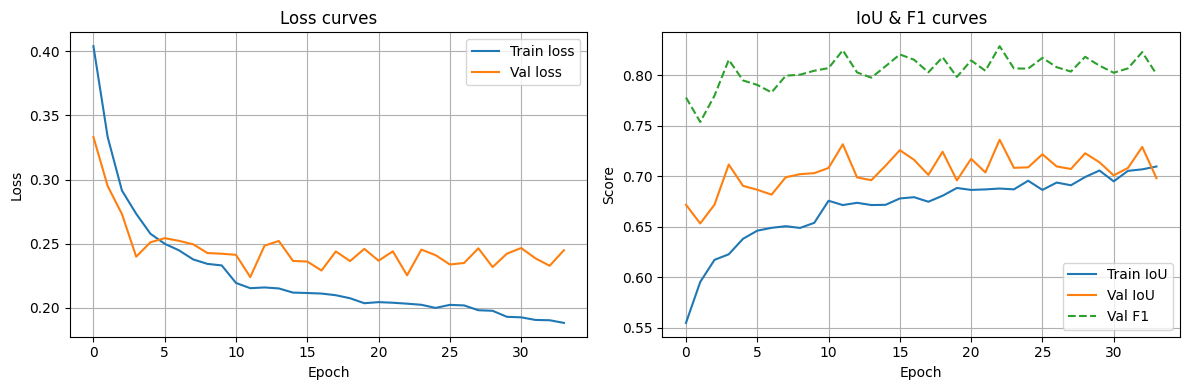

Saved to /content/drive/MyDrive/FloodProject/models/unet_spatial/training_curves.png


In [ ]:
## 6 — Plot Training Curves

import matplotlib.pyplot as plt

with open(LOG_PATH) as f:
    log = json.load(f)

epochs      = [e['epoch'] for e in log]
train_loss  = [e['train']['loss'] for e in log]
val_loss    = [e['val']['loss']   for e in log]
train_iou   = [e['train']['iou']  for e in log]
val_iou     = [e['val']['iou']    for e in log]
val_f1      = [e['val']['f1']     for e in log]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, train_loss, label='Train loss')
ax1.plot(epochs, val_loss,   label='Val loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss curves')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, train_iou, label='Train IoU')
ax2.plot(epochs, val_iou,   label='Val IoU')
ax2.plot(epochs, val_f1,    label='Val F1', linestyle='--')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Score')
ax2.set_title('IoU & F1 curves')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {MODEL_DIR}/training_curves.png')

In [ ]:
## 7 — Final Evaluation on Val Split

# Load best model
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

val_metrics = run_epoch(val_loader, training=False)

print('=== Final Val Metrics (best model) ===')
print(f'  IoU         : {val_metrics["iou"]:.4f}')
print(f'  F1          : {val_metrics["f1"]:.4f}')
print(f'  Precision   : {val_metrics["precision"]:.4f}')
print(f'  Recall      : {val_metrics["recall"]:.4f}')
print(f'  Specificity : {val_metrics["specificity"]:.4f}')
print(f'  Loss        : {val_metrics["loss"]:.4f}')

# Save final metrics
with open(f'{MODEL_DIR}/final_metrics.json', 'w') as f:
    json.dump(val_metrics, f, indent=2)
print(f'\nSaved to {MODEL_DIR}/final_metrics.json')

=== Final Val Metrics (best model) ===
  IoU         : 0.7360
  F1          : 0.8285
  Precision   : 0.8892
  Recall      : 0.7905
  Specificity : 0.9924
  Loss        : 0.2253

Saved to /content/drive/MyDrive/FloodProject/models/unet_spatial/final_metrics.json


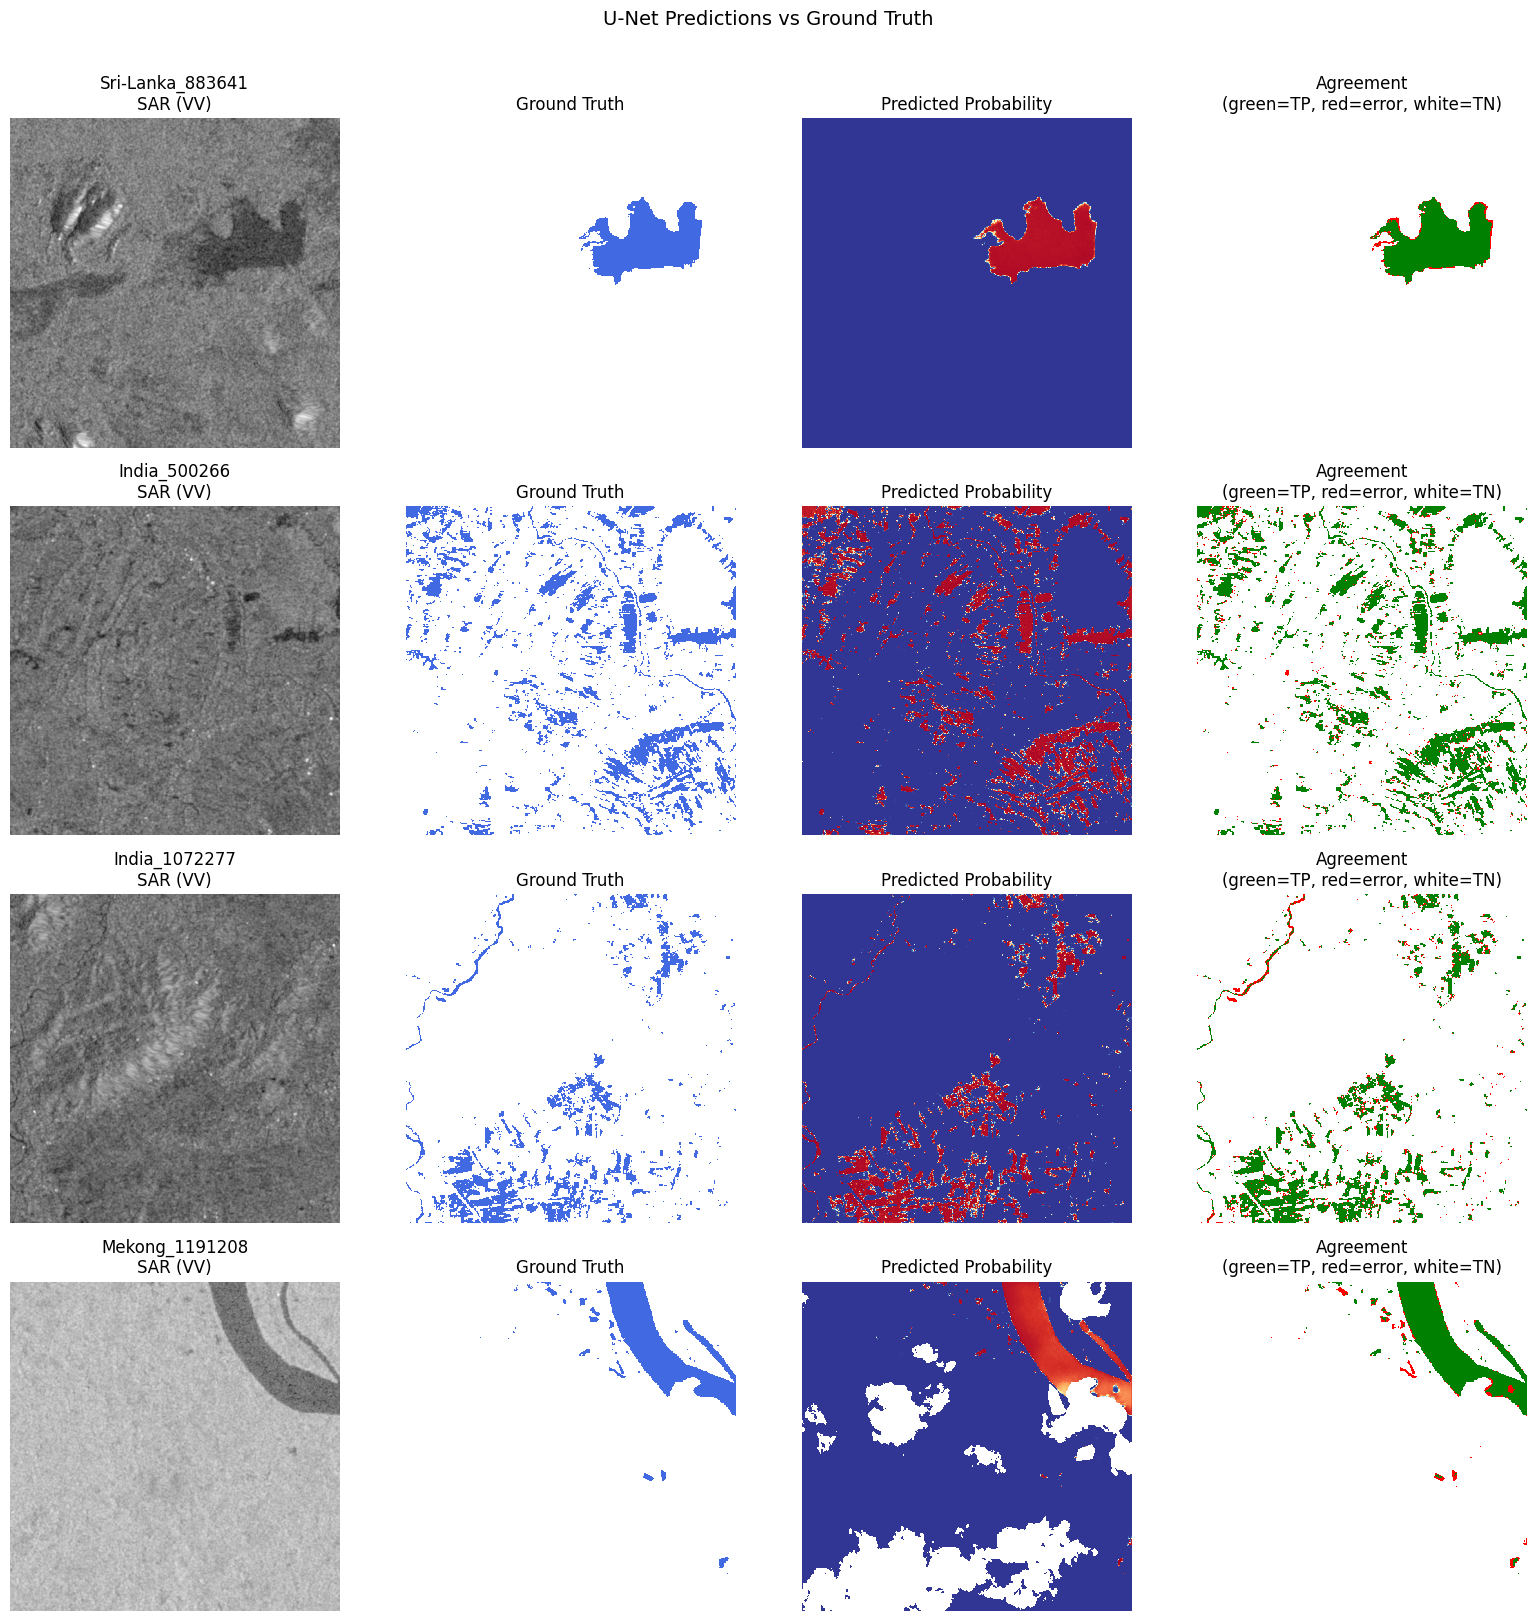

Saved to /content/drive/MyDrive/FloodProject/models/unet_spatial/prediction_viz.png


In [ ]:
# 8 — Visualizing predicted & actual flood map

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import random, glob, torch

# ── Pick a few random val chips to visualize ──────────────────────────────
val_files = glob.glob(f'{DATA_BASE}/val/*_spatial.npy')
sample_chips = random.sample(val_files, min(4, len(val_files)))

model.eval()
fig, axes = plt.subplots(len(sample_chips), 4, figsize=(16, 4 * len(sample_chips)))

# Color maps
cmap_flood = mcolors.ListedColormap(['white', 'royalblue'])  # 0=no flood, 1=flood
cmap_diff  = mcolors.ListedColormap(['white', 'green', 'red'])  # 0=TN, 1=TP, 2=FP/FN

for row, sp_path in enumerate(sample_chips):
    chip_id = os.path.basename(sp_path).replace('_spatial.npy', '')

    # Load
    spatial = np.load(f'{DATA_BASE}/val/{chip_id}_spatial.npy')  # (14, 512, 512)
    label   = np.load(f'{DATA_BASE}/val/{chip_id}_label.npy')    # (512, 512)

    # Predict
    with torch.no_grad():
        inp  = torch.from_numpy(spatial).unsqueeze(0).to(DEVICE)  # (1, 14, 512, 512)
        pred = torch.sigmoid(model(inp)).squeeze().cpu().numpy()   # (512, 512)
    pred_bin = (pred > 0.5).astype(np.int16)

    # Valid mask
    valid = (label != -1)
    label_vis   = np.where(valid, label,    -1)
    pred_vis    = np.where(valid, pred_bin, -1)

    # Agreement map: 0=TN, 1=TP, 2=FP or FN (disagreement)
    agree = np.where(~valid, -1,
            np.where((pred_bin == 1) & (label == 1), 1,   # TP → green
            np.where((pred_bin == 0) & (label == 0), 0,   # TN → white
            2)))                                            # FP/FN → red

    # Col 0: SAR false color (VV)
    ax = axes[row, 0]
    ax.imshow(spatial[0], cmap='gray')
    ax.set_title(f'{chip_id}\nSAR (VV)')
    ax.axis('off')

    # Col 1: Ground truth
    ax = axes[row, 1]
    gt_plot = np.ma.masked_where(label == -1, label)
    ax.imshow(gt_plot, cmap=cmap_flood, vmin=0, vmax=1, interpolation='none')
    ax.set_title('Ground Truth')
    ax.axis('off')

    # Col 2: Prediction probability
    ax = axes[row, 2]
    pred_plot = np.ma.masked_where(~valid, pred)
    ax.imshow(pred_plot, cmap='RdYlBu_r', vmin=0, vmax=1, interpolation='none')
    ax.set_title('Predicted Probability')
    ax.axis('off')

    # Col 3: Agreement (TP=green, FP/FN=red, TN=white)
    ax = axes[row, 3]
    agree_plot = np.ma.masked_where(agree == -1, agree)
    ax.imshow(agree_plot, cmap=cmap_diff, vmin=0, vmax=2, interpolation='none')
    ax.set_title('Agreement\n(green=TP, red=error, white=TN)')
    ax.axis('off')

plt.suptitle('U-Net Predictions vs Ground Truth', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/prediction_viz.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {MODEL_DIR}/prediction_viz.png')

Using device: cuda


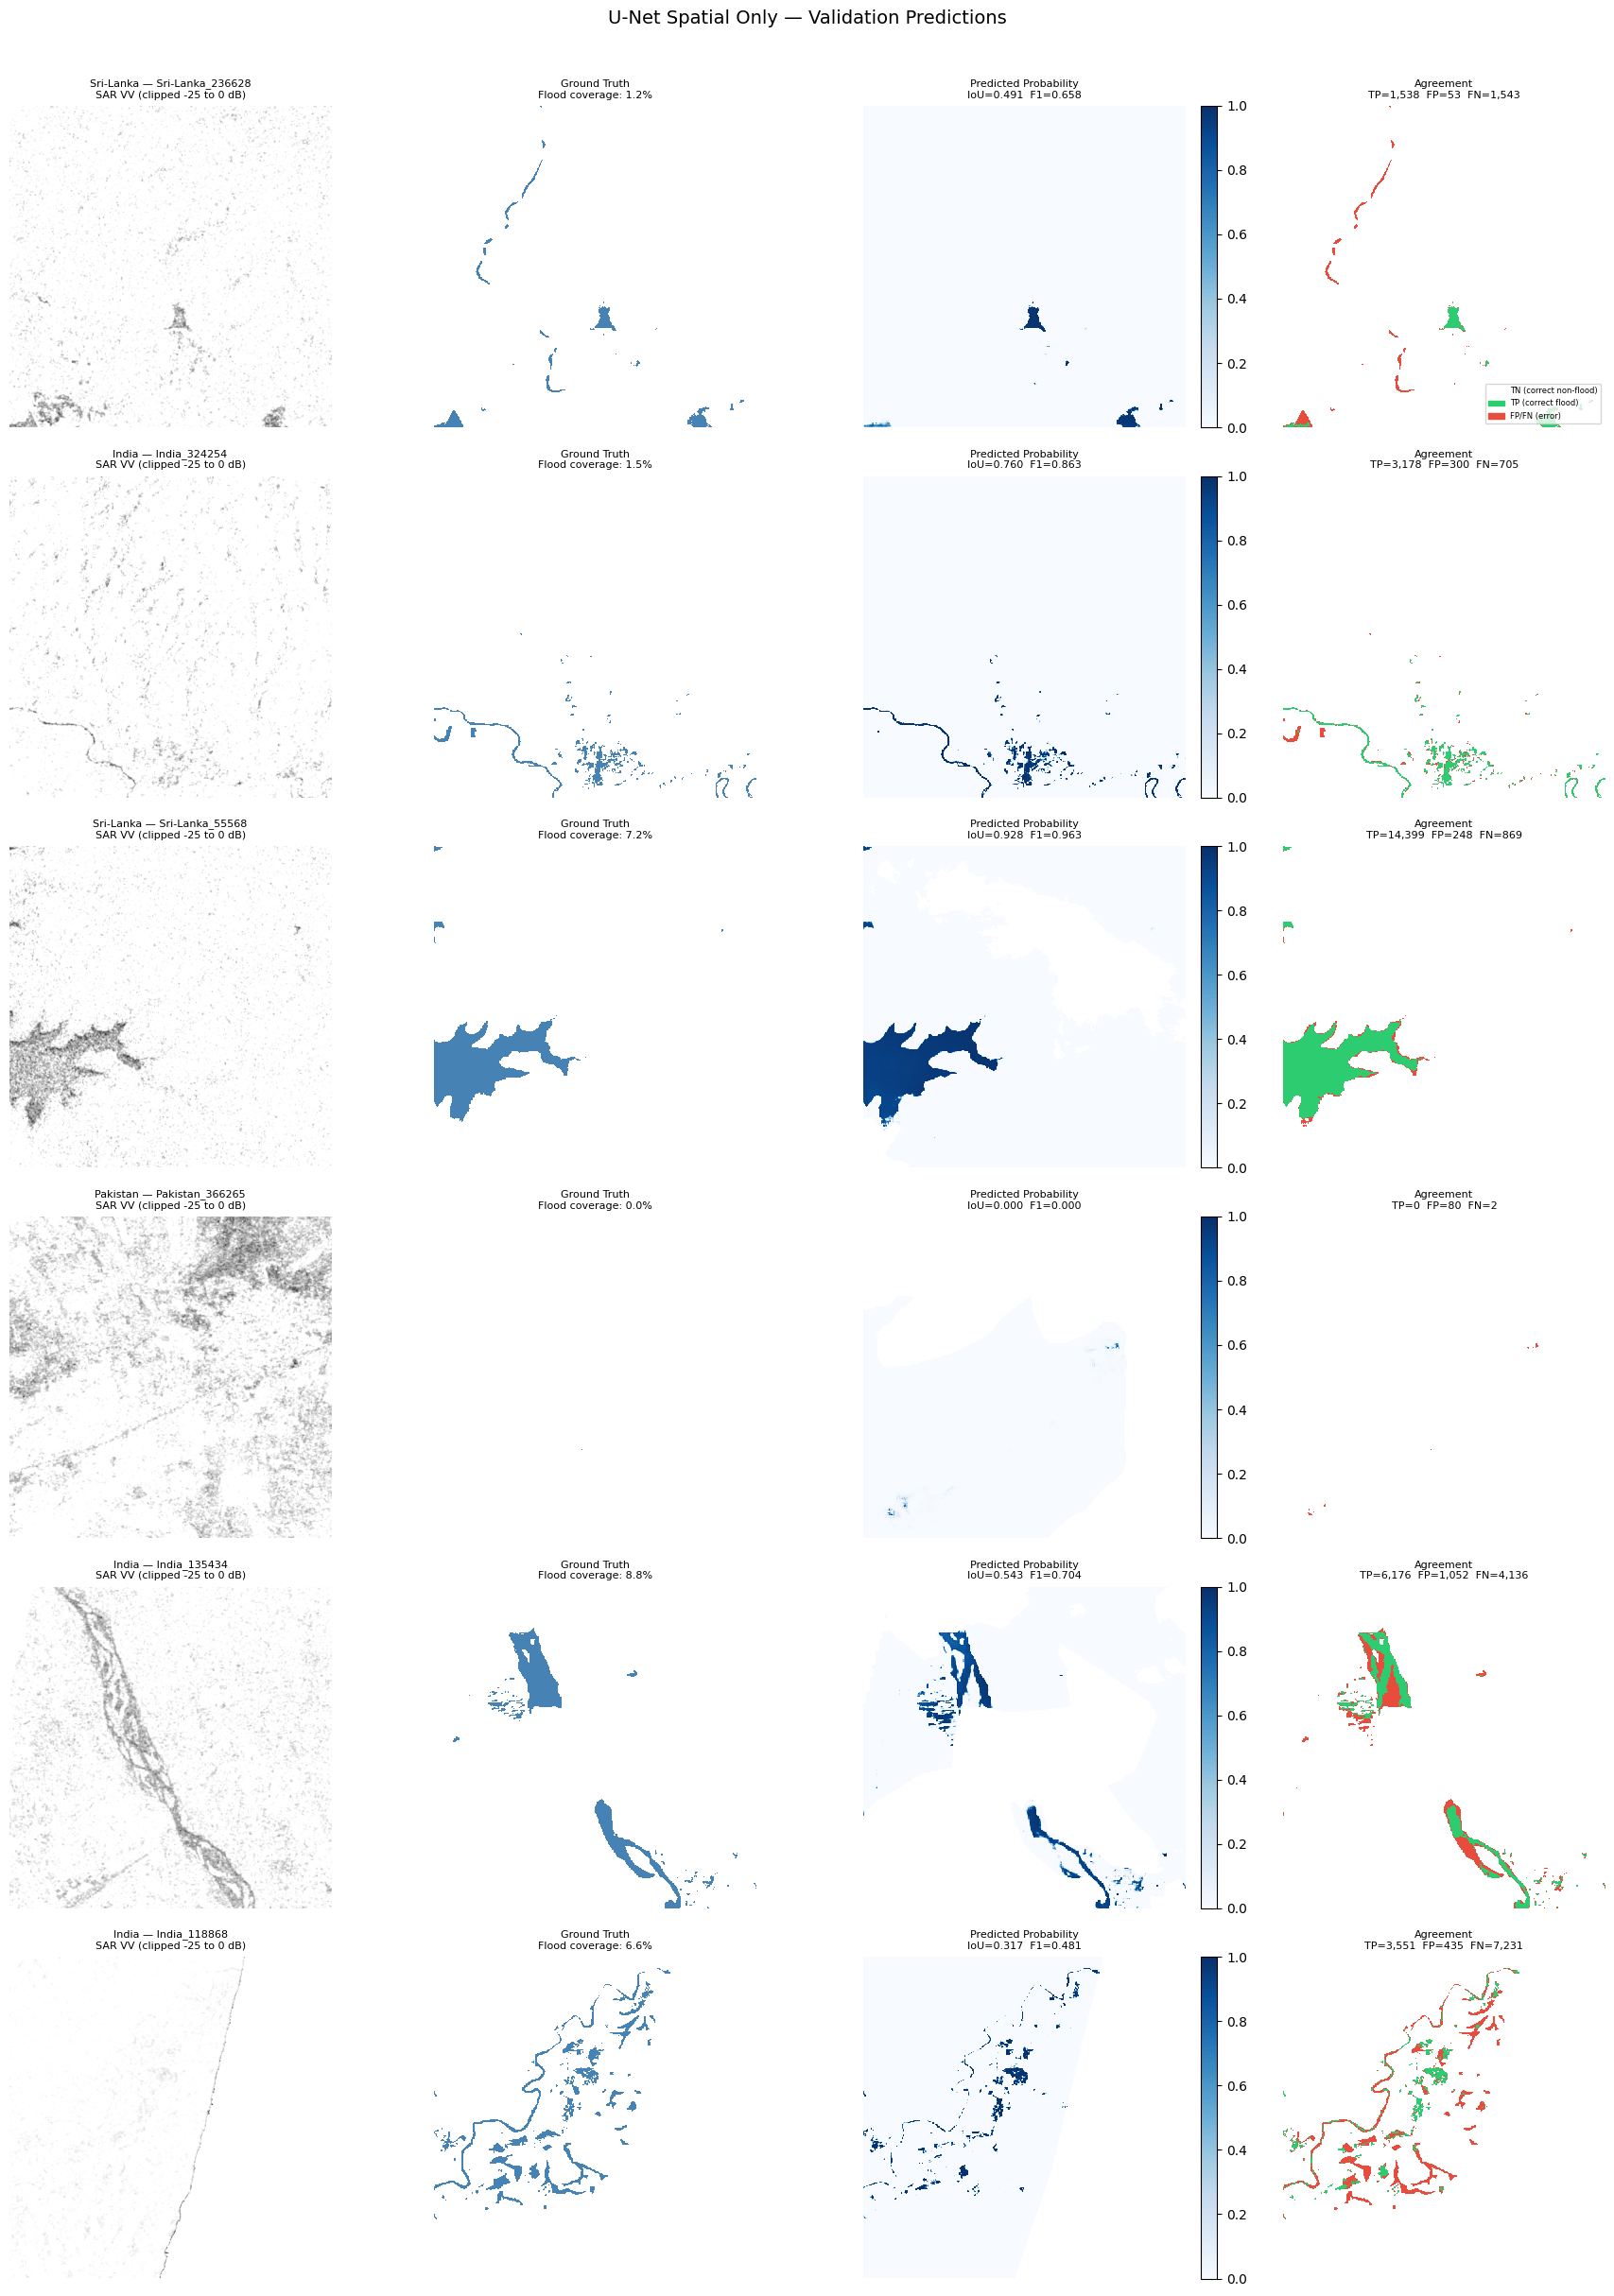

Saved to /content/drive/MyDrive/FloodProject/models/unet_spatial/prediction_viz.png


In [ ]:
import numpy as np, torch, glob, os, random
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── Config ────────────────────────────────────────────────────────────────
DATA_BASE  = '/content/drive/MyDrive/FloodProject/data/preprocessed'
MODEL_PATH = '/content/drive/MyDrive/FloodProject/models/unet_spatial/best_model.pth'
SAVE_PATH  = '/content/drive/MyDrive/FloodProject/models/unet_spatial/prediction_viz.png'

# ── Device — use GPU if available ─────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# ── Load model onto correct device ────────────────────────────────────────
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

# ── Pick 6 random val chips ───────────────────────────────────────────────
val_files = glob.glob(f'{DATA_BASE}/val/*_spatial.npy')
sample    = random.sample(val_files, min(6, len(val_files)))

# ── Color maps ────────────────────────────────────────────────────────────
# Ground truth: white=no flood, blue=flood, grey=invalid
cmap_gt   = mcolors.ListedColormap(['white', 'steelblue'])
# Prediction probability: white→blue gradient
cmap_pred = plt.cm.Blues
# Agreement: green=TP, red=FP/FN, white=TN, grey=invalid
cmap_agree = mcolors.ListedColormap(['white', '#2ecc71', '#e74c3c'])

fig, axes = plt.subplots(len(sample), 4, figsize=(18, 4 * len(sample)))
fig.suptitle('U-Net Spatial Only — Validation Predictions', fontsize=14, y=1.01)

for row, sp_path in enumerate(sample):
    chip_id = os.path.basename(sp_path).replace('_spatial.npy', '')
    country = chip_id.split('_')[0]

    # Load
    spatial = np.load(f'{DATA_BASE}/val/{chip_id}_spatial.npy')  # (14,512,512)
    label   = np.load(f'{DATA_BASE}/val/{chip_id}_label.npy')    # (512,512)

    # Predict — move input to same device as model
    with torch.no_grad():
        inp  = torch.from_numpy(spatial).unsqueeze(0).float().to(DEVICE)
        pred = torch.sigmoid(model(inp)).squeeze().cpu().numpy()  # back to CPU for plotting

    pred_bin = (pred > 0.5).astype(np.int16)
    valid    = (label != -1)

    # Per-chip IoU on valid pixels only
    tp  = np.logical_and(pred_bin == 1, label == 1) & valid
    fp  = np.logical_and(pred_bin == 1, label == 0) & valid
    fn  = np.logical_and(pred_bin == 0, label == 1) & valid
    iou = tp.sum() / (tp.sum() + fp.sum() + fn.sum() + 1e-6)
    f1  = 2*tp.sum() / (2*tp.sum() + fp.sum() + fn.sum() + 1e-6)

    # Agreement map: 0=TN, 1=TP, 2=error(FP/FN)
    agree = np.where(~valid, np.nan,
            np.where((pred_bin==1) & (label==1), 1,   # TP → green
            np.where((pred_bin==0) & (label==0), 0,   # TN → white
            2)))                                        # FP/FN → red

    # ── Col 0: SAR false color (VV channel) ──────────────────────────────
    # Clip to [-25, 0] dB range for better contrast
    vv = np.clip(spatial[0], -25, 0)
    vv_norm = (vv - vv.min()) / (vv.max() - vv.min() + 1e-6)
    axes[row, 0].imshow(vv_norm, cmap='gray', vmin=0, vmax=1)
    axes[row, 0].set_title(f'{country} — {chip_id}\nSAR VV (clipped -25 to 0 dB)', fontsize=8)
    axes[row, 0].axis('off')

    # ── Col 1: Ground truth ───────────────────────────────────────────────
    gt_masked = np.ma.masked_where(~valid, label)
    axes[row, 1].imshow(gt_masked, cmap=cmap_gt, vmin=0, vmax=1, interpolation='none')
    flood_pct = label[valid].sum() / valid.sum() * 100
    axes[row, 1].set_title(f'Ground Truth\nFlood coverage: {flood_pct:.1f}%', fontsize=8)
    axes[row, 1].axis('off')

    # ── Col 2: Prediction probability ────────────────────────────────────
    pred_masked = np.ma.masked_where(~valid, pred)
    im = axes[row, 2].imshow(pred_masked, cmap=cmap_pred, vmin=0, vmax=1, interpolation='none')
    axes[row, 2].set_title(f'Predicted Probability\nIoU={iou:.3f}  F1={f1:.3f}', fontsize=8)
    axes[row, 2].axis('off')
    plt.colorbar(im, ax=axes[row, 2], fraction=0.046, pad=0.04)

    # ── Col 3: Agreement map ──────────────────────────────────────────────
    agree_masked = np.ma.masked_invalid(agree)
    axes[row, 3].imshow(agree_masked, cmap=cmap_agree, vmin=0, vmax=2, interpolation='none')
    axes[row, 3].set_title(
        f'Agreement\nTP={tp.sum():,}  FP={fp.sum():,}  FN={fn.sum():,}',
        fontsize=8
    )
    axes[row, 3].axis('off')

    # Legend patches for agreement map (only on first row)
    if row == 0:
        from matplotlib.patches import Patch
        legend = [
            Patch(color='white',   label='TN (correct non-flood)'),
            Patch(color='#2ecc71', label='TP (correct flood)'),
            Patch(color='#e74c3c', label='FP/FN (error)'),
        ]
        axes[row, 3].legend(handles=legend, loc='lower right',
                            fontsize=6, framealpha=0.8)

plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {SAVE_PATH}')